# xPts model evaluation

This notebook evaluates the saved, leakage-safe walk-forward forecasts for the team, minutes, attacking, defensive, miscellaneous-event, and bonus models, then reconstructs an overall expected-points forecast from their point contributions.

The primary overall holdout is **2025–26**, because it is the latest complete season in the persisted bonus walk-forward forecasts and uses the current defensive-contribution scoring era. The pooled 2024–25/2025–26 view is still useful for sample size, but it is labelled mixed-era: 2024–25 did not contain defensive-contribution points, so its comparable xPts forecast removes that expected contribution before comparing with realised FPL points.

The notebook works at two grains:

- player-fixture for component accuracy and fixture xPts;
- player-gameweek for ranking usefulness, aggregating double gameweeks before measuring top-k selection.

The overall xPts forecast is reconstructed additively from expected point contributions. This is valid for expected values and preserves the persisted fixture-level Monte Carlo expected bonus. It does not claim that the underlying events are independent, and it does not rerun the historical simulator because historical scoreline probability matrices were not persisted.

In [1]:
import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from IPython.display import Markdown, display
from scipy.stats import spearmanr
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    mean_absolute_error,
    mean_poisson_deviance,
    mean_squared_error,
    roc_auc_score,
)

warnings.filterwarnings('ignore', category=RuntimeWarning)
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'

In [2]:
def find_repo_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'models').is_dir() and (candidate / 'backend' / 'src').is_dir():
            return candidate
    raise FileNotFoundError('Could not find the repository root from the notebook working directory')

ROOT = find_repo_root()
DATA_ROOT = ROOT / 'data'
MODELS_ROOT = DATA_ROOT / 'models'
CONFIG_PATH = ROOT / 'configs' / 'inference.yaml'
SETTINGS = yaml.safe_load(CONFIG_PATH.read_text(encoding='utf-8'))['inference']
RULES = SETTINGS['rules']

MODEL_DIRS = {
    'team_score': MODELS_ROOT / 'team_score',
    'minutes_state': MODELS_ROOT / 'minutes_state',
    'attacking': MODELS_ROOT / 'attacking',
    'defensive': MODELS_ROOT / 'defensive',
    'misc_events': MODELS_ROOT / 'misc_events',
    'bonus': MODELS_ROOT / 'bonus',
}
PLAYER_KEYS = ['season', 'fixture_id', 'player_key']
TEAM_KEYS = ['season', 'fixture_id', 'team_key']
FIXTURE_KEYS = ['season', 'fixture_id']

ruleset_version = RULES['version']
display(Markdown(f'**Repository:** `{ROOT}`'))
display(Markdown(f'**Ruleset:** `{ruleset_version}`'))

**Repository:** `c:\Users\Alex\Desktop\Personal Programming\xLthm - xPts`

**Ruleset:** `2026-27`

## 1. Artifact inventory and validation design

All metrics below are recomputed from the prediction CSVs rather than copied from `metrics.json`. The packaged metrics are retained for cross-checking and for model-specific baselines/caveats. Walk-forward means each validation season was predicted using only earlier seasons, but the downstream models have different available validation windows; coverage is therefore shown before any comparison.

In [3]:
def read_json(path):
    return json.loads(path.read_text(encoding='utf-8'))

metadata = {name: read_json(path / 'metadata.json') for name, path in MODEL_DIRS.items()}
packaged_metrics = {name: read_json(path / 'metrics.json') for name, path in MODEL_DIRS.items()}

inventory = pd.DataFrame([
    {
        'model': name,
        'trained_at': meta.get('trained_at'),
        'validation_seasons': ', '.join(meta.get('validation_seasons', [])),
        'validation_method': meta.get('validation_method', ''),
        'feature_profile': meta.get('feature_profile', ''),
        'feature_count': meta.get('feature_count'),
    }
    for name, meta in metadata.items()
])
display(inventory)

,model,trained_at,validation_seasons,validation_method,feature_profile,feature_count
0,team_score,2026-08-30T16:04:12.533422+00:00,"2023-24, 2024-25, 2025-26",expanding-window season walk-forward,score_xg_and_team_identity,80.0000
1,minutes_state,2026-09-05T14:23:42.989869+00:00,"2023-24, 2024-25, 2025-26",expanding-window season walk-forward,usage_context_and_market,44.0000
2,attacking,2026-08-30T17:34:47.611819+00:00,"2023-24, 2024-25, 2025-26",expanding-window season walk-forward,expected_history_and_market,144.0000
3,defensive,2026-08-30T20:09:14.952439+00:00,,season walk-forward for saves; expanding gamew...,,NaN
4,misc_events,2026-08-30T19:57:14.412222+00:00,,expanding-window season walk-forward,,NaN
5,bonus,2026-08-30T20:11:29.630668+00:00,"2024-25, 2025-26",expanding-window season walk-forward using onl...,,NaN


In [4]:
prediction_files = {
    'team_score_team': MODEL_DIRS['team_score'] / 'walk_forward_team_predictions.csv',
    'team_score_fixture': MODEL_DIRS['team_score'] / 'walk_forward_fixture_predictions.csv',
    'minutes_state': MODEL_DIRS['minutes_state'] / 'walk_forward_predictions.csv',
    'attacking': MODEL_DIRS['attacking'] / 'walk_forward_predictions.csv',
    'defensive': MODEL_DIRS['defensive'] / 'walk_forward_predictions.csv',
    'misc_events': MODEL_DIRS['misc_events'] / 'walk_forward_predictions.csv',
    'bonus': MODEL_DIRS['bonus'] / 'walk_forward_predictions.csv',
}
predictions = {name: pd.read_csv(path, low_memory=False) for name, path in prediction_files.items()}

coverage = pd.DataFrame([
    {
        'prediction_set': name,
        'rows': len(frame),
        'seasons': ', '.join(map(str, sorted(frame['season'].dropna().unique()))),
        'fixtures': frame[FIXTURE_KEYS].drop_duplicates().shape[0],
        'players': frame['player_key'].nunique() if 'player_key' in frame else np.nan,
    }
    for name, frame in predictions.items()
])
display(coverage)

for name, frame in predictions.items():
    key = PLAYER_KEYS if 'player_key' in frame else (TEAM_KEYS if 'team_key' in frame else FIXTURE_KEYS)
    duplicate_count = int(frame.duplicated(key).sum())
    assert duplicate_count == 0, f'{name} has {duplicate_count:,} duplicate prediction keys'
    print(f'{name}: no duplicate {key} rows')

,prediction_set,rows,seasons,fixtures,players
0,team_score_team,2280,"2023-24, 2024-25, 2025-26",1140,NaN
1,team_score_fixture,1140,"2023-24, 2024-25, 2025-26",1140,NaN
2,minutes_state,86755,"2023-24, 2024-25, 2025-26",1140,"1,400.0000"
3,attacking,86755,"2023-24, 2024-25, 2025-26",1140,"1,400.0000"
4,defensive,86755,"2023-24, 2024-25, 2025-26",1140,"1,400.0000"
5,misc_events,86755,"2023-24, 2024-25, 2025-26",1140,"1,400.0000"
6,bonus,57030,"2024-25, 2025-26",760,"1,091.0000"


team_score_team: no duplicate ['season', 'fixture_id', 'team_key'] rows
team_score_fixture: no duplicate ['season', 'fixture_id'] rows
minutes_state: no duplicate ['season', 'fixture_id', 'player_key'] rows
attacking: no duplicate ['season', 'fixture_id', 'player_key'] rows
defensive: no duplicate ['season', 'fixture_id', 'player_key'] rows
misc_events: no duplicate ['season', 'fixture_id', 'player_key'] rows
bonus: no duplicate ['season', 'fixture_id', 'player_key'] rows


### Metric helpers

For count outcomes, MAE/RMSE describe forecast size error while Poisson deviance gives a likelihood-sensitive measure. For binary outcomes, Brier score rewards calibrated probabilities and log loss penalises confident mistakes; ROC AUC is included only as a ranking statistic. The tables also retain prevalence and mean forecast so a low error on a rare event is not read without context.

In [5]:
def valid_arrays(actual, predicted):
    actual = pd.to_numeric(pd.Series(actual), errors='coerce')
    predicted = pd.to_numeric(pd.Series(predicted), errors='coerce')
    valid = actual.notna() & predicted.notna()
    return actual.loc[valid].to_numpy(float), predicted.loc[valid].to_numpy(float)

def count_metrics(frame, actual_col, predicted_col, label=None, poisson=True):
    actual, predicted = valid_arrays(frame[actual_col], frame[predicted_col])
    if len(actual) == 0:
        return {'metric': label or predicted_col, 'n': 0}
    poisson_deviance = mean_poisson_deviance(actual, np.clip(predicted, 1e-9, None)) if poisson and np.all(actual >= 0) else np.nan
    return {
        'metric': label or predicted_col,
        'n': len(actual),
        'actual_mean': actual.mean(),
        'predicted_mean': predicted.mean(),
        'bias_pred_minus_actual': (predicted - actual).mean(),
        'mae': mean_absolute_error(actual, predicted),
        'rmse': np.sqrt(mean_squared_error(actual, predicted)),
        'poisson_deviance': poisson_deviance,
    }

def binary_metrics(frame, actual_col, probability_col, label=None):
    actual, probability = valid_arrays(frame[actual_col], frame[probability_col])
    probability = np.clip(probability, 1e-9, 1 - 1e-9)
    if len(actual) == 0:
        return {'metric': label or probability_col, 'n': 0}
    result = {
        'metric': label or probability_col,
        'n': len(actual),
        'actual_rate': actual.mean(),
        'predicted_rate': probability.mean(),
        'brier': brier_score_loss(actual, probability),
        'log_loss': log_loss(actual, probability, labels=[0, 1]),
    }
    result['roc_auc'] = roc_auc_score(actual, probability) if np.unique(actual).size == 2 else np.nan
    return result

def multiclass_brier(actual, probabilities):
    actual = np.asarray(actual, dtype=int)
    probabilities = np.asarray(probabilities, dtype=float)
    one_hot = np.eye(probabilities.shape[1])[actual]
    return np.mean(np.square(probabilities - one_hot).sum(axis=1))

def calibration_table(frame, actual_col, probability_col, bins=10, strategy='quantile'):
    values = frame[[actual_col, probability_col]].copy().dropna()
    if values.empty:
        return pd.DataFrame()
    values[probability_col] = values[probability_col].clip(0, 1)
    if strategy == 'quantile':
        values['bin'] = pd.qcut(values[probability_col], q=bins, duplicates='drop')
    else:
        edges = np.linspace(0, 1, bins + 1)
        values['bin'] = pd.cut(values[probability_col], edges, include_lowest=True)
    result = values.groupby('bin', observed=True).agg(
        n=(actual_col, 'size'),
        mean_predicted=(probability_col, 'mean'),
        observed_rate=(actual_col, 'mean'),
    ).reset_index(drop=True)
    result['bias'] = result['mean_predicted'] - result['observed_rate']
    result['ci95'] = 1.96 * np.sqrt(result['observed_rate'] * (1 - result['observed_rate']) / result['n'])
    return result

def plot_calibration(frame, actual_col, probability_col, title, ax=None, bins=10):
    table = calibration_table(frame, actual_col, probability_col, bins=bins)
    ax = ax or plt.gca()
    if table.empty:
        ax.set_title(f'{title} (no data)')
        return table
    ax.errorbar(table['mean_predicted'], table['observed_rate'], yerr=table['ci95'], fmt='o-', capsize=3)
    ax.plot([0, 1], [0, 1], '--', color='black', linewidth=1)
    ax.set(xlim=(0, 1), ylim=(0, 1), xlabel='Mean predicted probability', ylabel='Observed rate', title=title)
    return table

def season_metric_table(frame, metric_fn, seasons=None):
    seasons = seasons or sorted(frame['season'].dropna().unique())
    rows = []
    for season in seasons:
        subset = frame.loc[frame['season'].eq(season)]
        rows.append({'season': season, **metric_fn(subset)})
    return pd.DataFrame(rows)

## 2. Team-score model

This model is evaluated at team-fixture and fixture grains. Goals are count forecasts; clean sheets are binary probabilities; result and exact-score probabilities are evaluated as distributions. The result Brier score below is the multiclass squared error, not the binary Brier convention used for clean sheets.

In [6]:
team_score = predictions['team_score_team'].copy()
fixture_score = predictions['team_score_fixture'].copy()

team_count_metrics = pd.DataFrame([
    count_metrics(team_score, 'actual_goals_for', 'expected_goals_for', 'goals for'),
    count_metrics(team_score, 'actual_goals_against', 'expected_goals_against', 'goals against'),
])
team_binary_metrics = pd.DataFrame([
    binary_metrics(team_score, 'actual_clean_sheet', 'clean_sheet_probability', 'clean sheet'),
])
display(team_count_metrics)
display(team_binary_metrics)

result_actual = np.select(
    [fixture_score['actual_home_goals'] > fixture_score['actual_away_goals'], fixture_score['actual_home_goals'].eq(fixture_score['actual_away_goals'])],
    [0, 1],
    default=2,
)
result_probabilities = fixture_score[['home_win_probability', 'draw_probability', 'away_win_probability']].to_numpy(float)
result_probabilities = result_probabilities / result_probabilities.sum(axis=1, keepdims=True)
result_metrics = pd.DataFrame([{
    'fixtures': len(fixture_score),
    'result_log_loss': log_loss(result_actual, result_probabilities, labels=[0, 1, 2]),
    'result_brier_multiclass': multiclass_brier(result_actual, result_probabilities),
    'exact_score_log_loss': -np.log(np.clip(fixture_score['actual_score_probability'], 1e-12, 1)).mean(),
    'most_likely_score_accuracy': (
        (fixture_score['most_likely_home_goals'].eq(fixture_score['actual_home_goals']) & fixture_score['most_likely_away_goals'].eq(fixture_score['actual_away_goals']))
    ).mean(),
}])
display(result_metrics)

,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance
0,goals for,2280,1.4939,1.4378,-0.0561,0.9508,1.2039,1.1349
1,goals against,2280,1.4939,1.4378,-0.0561,0.9508,1.2039,1.1349


,metric,n,actual_rate,predicted_rate,brier,log_loss,roc_auc
0,clean sheet,2280,0.2320,0.2585,0.1735,0.5264,0.6281


,fixtures,result_log_loss,result_brier_multiclass,exact_score_log_loss,most_likely_score_accuracy
0,1140,1.0155,0.6088,3.0368,0.1140


,season,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance,actual_rate,predicted_rate,brier,log_loss,roc_auc
0,2023-24,goals for,760,1.6395,1.4000,-0.2395,1.0157,1.3029,1.2064,0.2066,0.2699,0.1645,0.5055,0.6244
1,2024-25,goals for,760,1.4671,1.4730,0.0059,0.9323,1.1894,1.1080,0.2342,0.2524,0.1729,0.5249,0.6390
2,2025-26,goals for,760,1.3750,1.4403,0.0653,0.9045,1.1117,1.0905,0.2553,0.2533,0.1832,0.5490,0.6277


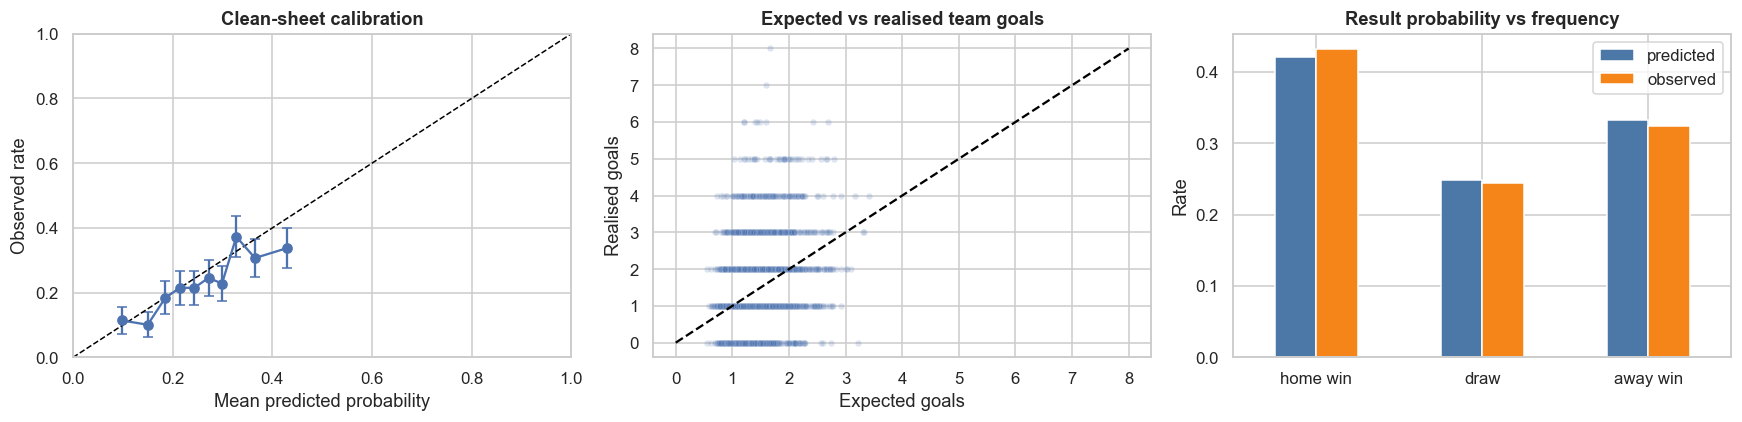

In [7]:
team_by_season = pd.concat([
    season_metric_table(team_score, lambda f: count_metrics(f, 'actual_goals_for', 'expected_goals_for', 'goals for')),
    season_metric_table(team_score, lambda f: binary_metrics(f, 'actual_clean_sheet', 'clean_sheet_probability', 'clean sheet')).drop(columns='metric'),
], axis=1)
display(team_by_season.loc[:, ~team_by_season.columns.duplicated()])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_calibration(team_score, 'actual_clean_sheet', 'clean_sheet_probability', 'Clean-sheet calibration', axes[0])
sns.scatterplot(data=team_score.sample(min(3000, len(team_score)), random_state=7), x='expected_goals_for', y='actual_goals_for', alpha=0.18, s=18, ax=axes[1])
goal_limit = max(team_score['expected_goals_for'].max(), team_score['actual_goals_for'].max())
axes[1].plot([0, goal_limit], [0, goal_limit], '--', color='black')
axes[1].set(title='Expected vs realised team goals', xlabel='Expected goals', ylabel='Realised goals')
result_means = pd.DataFrame({
    'predicted': [fixture_score['home_win_probability'].mean(), fixture_score['draw_probability'].mean(), fixture_score['away_win_probability'].mean()],
    'observed': [(result_actual == 0).mean(), (result_actual == 1).mean(), (result_actual == 2).mean()],
}, index=['home win', 'draw', 'away win'])
result_means.plot.bar(ax=axes[2], color=['#4c78a8', '#f58518'])
axes[2].set(title='Result probability vs frequency', ylabel='Rate', xlabel='')
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()

## 3. Minutes-state model

Minutes are a structured five-state problem, so the state distribution is assessed directly as well as through the derived appearance, start, and 60-plus probabilities. Expected minutes is evaluated separately; a good appearance classifier can still produce biased durations.

In [8]:
minutes = predictions['minutes_state'].copy()
state_names = ['did_not_play', 'sub_under_60', 'sub_60_plus', 'start_under_60', 'start_60_plus']
state_probability_cols = [f'probability_{state}' for state in state_names]
state_frame = minutes.dropna(subset=['actual_minutes_state']).copy()
state_actual = pd.Categorical(state_frame['actual_minutes_state'], categories=state_names).codes
state_probabilities = state_frame[state_probability_cols].to_numpy(float)
state_probabilities = state_probabilities / state_probabilities.sum(axis=1, keepdims=True)
minutes_state_metrics = pd.DataFrame([{
    'rows': len(state_frame),
    'state_log_loss': log_loss(state_actual, state_probabilities, labels=range(len(state_names))),
    'state_brier_multiclass': multiclass_brier(state_actual, state_probabilities),
    'state_accuracy': accuracy_score(state_actual, state_probabilities.argmax(axis=1)),
}])
binary_minutes_metrics = pd.DataFrame([
    binary_metrics(minutes, 'actual_appeared', 'appearance_probability', 'appearance'),
    binary_metrics(minutes, 'actual_started', 'start_probability', 'started'),
    binary_metrics(minutes, 'actual_sixty_plus', 'sixty_plus_probability', '60-plus'),
])
duration_metrics = pd.DataFrame([count_metrics(minutes, 'actual_minutes', 'expected_minutes', 'minutes')])
appeared_minutes = minutes.loc[minutes['actual_appeared'].eq(1)]
duration_metrics = pd.concat([duration_metrics, pd.DataFrame([count_metrics(appeared_minutes, 'actual_minutes', 'expected_minutes', 'minutes | appeared only')])], ignore_index=True)
display(minutes_state_metrics)
display(binary_minutes_metrics)
display(duration_metrics)

,rows,state_log_loss,state_brier_multiclass,state_accuracy
0,86755,0.4941,0.2545,0.8189


,metric,n,actual_rate,predicted_rate,brier,log_loss,roc_auc
0,appearance,86755,0.3970,0.3982,0.0806,0.2645,0.9550
1,started,86755,0.2891,0.2884,0.0747,0.2402,0.9569
2,60-plus,86755,0.2707,0.2695,0.0790,0.2511,0.9504


,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance
0,minutes,86755,25.8849,26.0754,0.1904,12.2933,21.1791,16.4075
1,minutes | appeared only,34442,65.2008,55.3147,-9.8861,20.5993,27.0720,20.5967


,season,appearance_actual_rate,appearance_predicted_rate,appearance_brier,appearance_log_loss,appearance_roc_auc,minutes_actual_mean,minutes_predicted_mean,minutes_bias_pred_minus_actual,minutes_mae,minutes_rmse,minutes_poisson_deviance,n
0,2023-24,0.3830,0.3802,0.0819,0.2685,0.9532,25.1852,25.3130,0.1278,12.2865,21.1682,16.5649,29725
1,2024-25,0.4239,0.4266,0.0859,0.2808,0.9500,27.4333,27.7426,0.3093,13.0116,21.9256,17.4822,27283
2,2025-26,0.3863,0.3900,0.0743,0.2456,0.9608,25.1639,25.3080,0.1440,11.6412,20.4818,15.2645,29747


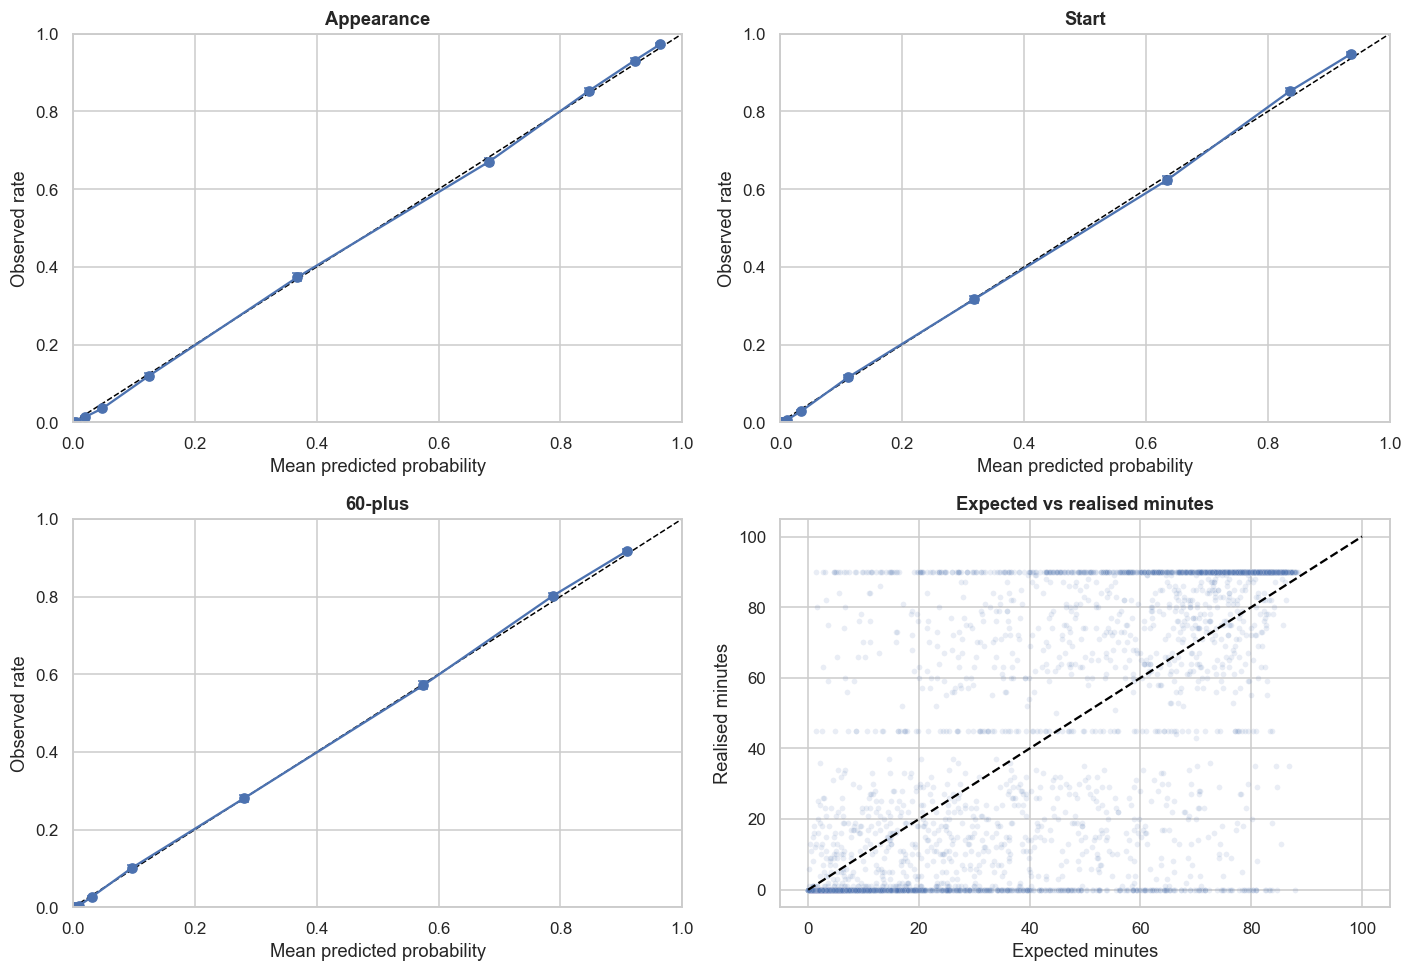

In [9]:
minutes_by_season = []
for season, group in minutes.groupby('season'):
    row = {'season': season}
    row.update({f'appearance_{key}': value for key, value in binary_metrics(group, 'actual_appeared', 'appearance_probability').items() if key not in {'metric', 'n'}})
    row.update({f'minutes_{key}': value for key, value in count_metrics(group, 'actual_minutes', 'expected_minutes').items() if key not in {'metric', 'n'}})
    row['n'] = len(group)
    minutes_by_season.append(row)
display(pd.DataFrame(minutes_by_season))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (actual_col, probability_col, title) in zip(axes.flat[:3], [
    ('actual_appeared', 'appearance_probability', 'Appearance'),
    ('actual_started', 'start_probability', 'Start'),
    ('actual_sixty_plus', 'sixty_plus_probability', '60-plus'),
]):
    plot_calibration(minutes, actual_col, probability_col, title, ax)
sample = minutes.sample(min(6000, len(minutes)), random_state=7)
sns.scatterplot(data=sample, x='expected_minutes', y='actual_minutes', alpha=0.12, s=14, ax=axes[1, 1])
axes[1, 1].plot([0, 100], [0, 100], '--', color='black')
axes[1, 1].set(title='Expected vs realised minutes', xlabel='Expected minutes', ylabel='Realised minutes')
plt.tight_layout()

## 4. Attacking model

Goals and assists are evaluated both as counts and as event probabilities. The xG/xA target is only available for rows where the source data is valid, so those rows are reported separately. The reconciliation check is important: the attacking model is designed to allocate the team expected-goals forecast across the complete player set.

In [10]:
attacking = predictions['attacking'].copy()
attacking_count = pd.DataFrame([
    count_metrics(attacking, 'actual_goals', 'expected_goals', 'goals'),
    count_metrics(attacking, 'actual_assists', 'expected_fpl_assists', 'FPL assists'),
])
attacking_events = pd.DataFrame([
    binary_metrics(attacking.assign(actual_goal_event=attacking['actual_goals'].gt(0)), 'actual_goal_event', 'goal_probability', 'any goal'),
    binary_metrics(attacking.assign(actual_assist_event=attacking['actual_assists'].gt(0)), 'actual_assist_event', 'assist_probability', 'any assist'),
])
expected_data = attacking.loc[attacking['expected_data_available'].astype(bool)].copy()
xg_metrics = pd.DataFrame([
    count_metrics(expected_data, 'actual_xg', 'expected_goals', 'xG target vs goal forecast'),
    count_metrics(expected_data, 'actual_xa', 'expected_fpl_assists', 'xA target vs FPL-assist forecast'),
])
display(attacking_count)
display(attacking_events)
display(xg_metrics)

,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance
0,goals,86755,0.0378,0.0378,-0.0000,0.0631,0.1958,0.1587
1,FPL assists,86755,0.0345,0.0341,-0.0004,0.0605,0.1888,0.1665


,metric,n,actual_rate,predicted_rate,brier,log_loss,roc_auc
0,any goal,86755,0.0342,0.0347,0.0284,0.1033,0.9107
1,any assist,86755,0.0319,0.0320,0.0283,0.1067,0.8808


,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance
0,xG target vs goal forecast,86755,0.0388,0.0378,-0.0010,0.0430,0.1200,0.0823
1,xA target vs FPL-assist forecast,86755,0.0247,0.0341,0.0093,0.0311,0.0722,0.0510


,season,position,n,goals_actual_mean,goals_predicted_mean,goals_bias_pred_minus_actual,goals_mae,goals_rmse,goals_poisson_deviance,assists_actual_mean,assists_predicted_mean,assists_bias_pred_minus_actual,assists_mae,assists_rmse,assists_poisson_deviance
0,2023-24,DEF,9611,0.0165,0.0181,0.0016,0.0332,0.1294,0.1097,0.0252,0.0256,0.0005,0.0464,0.1613,0.1376
1,2023-24,FWD,3854,0.0960,0.0809,-0.0151,0.1352,0.3223,0.2973,0.0436,0.0305,-0.0131,0.0658,0.2146,0.1954
2,2023-24,GK,3413,0.0000,0.0011,0.0011,0.0011,0.0024,0.0023,0.0006,0.0018,0.0012,0.0024,0.0243,0.0083
3,2023-24,MID,12847,0.0519,0.0447,-0.0072,0.0814,0.2299,0.2062,0.0513,0.0456,-0.0057,0.0835,0.2334,0.2169
4,2024-25,DEF,9146,0.0139,0.0186,0.0048,0.0311,0.1163,0.0944,0.0211,0.0264,0.0053,0.0440,0.1463,0.1243
5,2024-25,FWD,3018,0.1097,0.1003,-0.0093,0.1490,0.3106,0.2949,0.0381,0.0317,-0.0064,0.0624,0.1999,0.1796
6,2024-25,GK,2869,0.0000,0.0010,0.0010,0.0010,0.0018,0.0019,0.0038,0.0014,-0.0024,0.0052,0.0617,0.0362
7,2024-25,MID,12250,0.0509,0.0525,0.0017,0.0870,0.2274,0.2116,0.0538,0.0545,0.0007,0.0929,0.2351,0.2320
8,2025-26,DEF,9733,0.0141,0.0199,0.0058,0.0325,0.1245,0.1009,0.0244,0.0280,0.0037,0.0485,0.1556,0.1437
9,2025-26,FWD,3278,0.1022,0.0975,-0.0047,0.1518,0.3257,0.3375,0.0326,0.0255,-0.0071,0.0538,0.1874,0.1806


,team-fixtures,mean_abs_reconciliation_error,max_abs_reconciliation_error,allocated_goals_mae
0,2280,0.0000,0.0000,0.9508


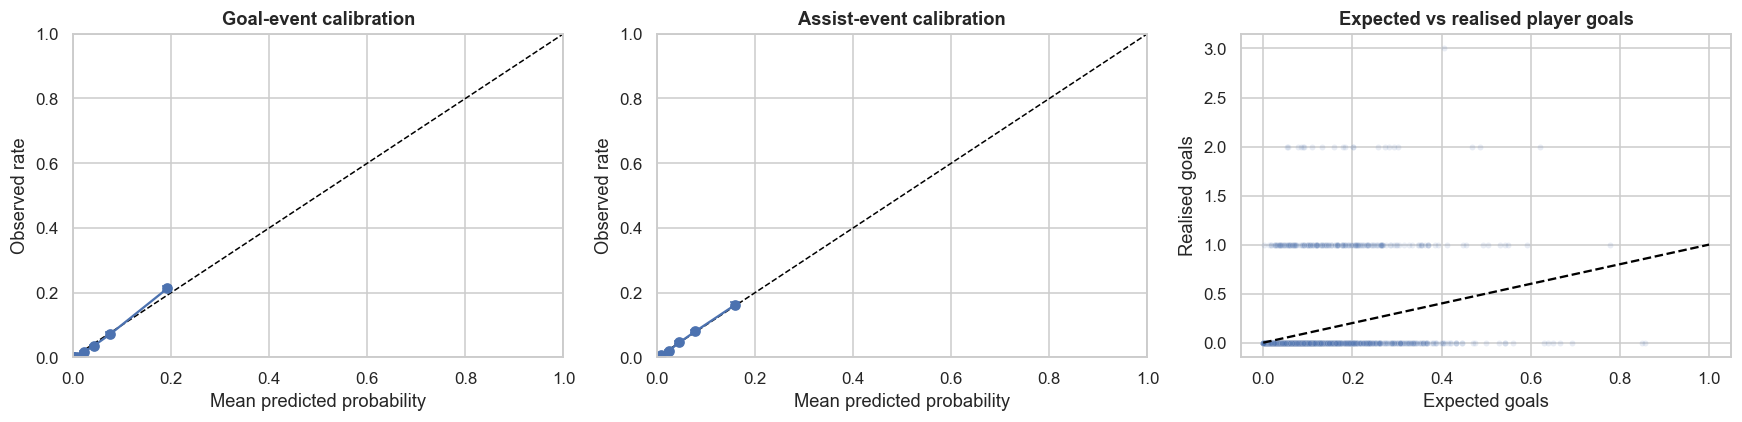

In [11]:
attacking_season_position = []
for (season, position), group in attacking.groupby(['season', 'position']):
    row = {'season': season, 'position': position, 'n': len(group)}
    row.update({f'goals_{key}': value for key, value in count_metrics(group, 'actual_goals', 'expected_goals').items() if key not in {'metric', 'n'}})
    row.update({f'assists_{key}': value for key, value in count_metrics(group, 'actual_assists', 'expected_fpl_assists').items() if key not in {'metric', 'n'}})
    attacking_season_position.append(row)
display(pd.DataFrame(attacking_season_position))

team_allocated = attacking.groupby(TEAM_KEYS, as_index=False).agg(
    allocated_expected_goals=('expected_goals', 'sum'),
    allocated_expected_assists=('expected_fpl_assists', 'sum'),
)
team_expected = predictions['team_score_team'][TEAM_KEYS + ['expected_goals_for', 'actual_goals_for']].drop_duplicates(TEAM_KEYS)
reconciliation = team_allocated.merge(team_expected, on=TEAM_KEYS, how='inner', validate='one_to_one')
reconciliation['goal_reconciliation_error'] = reconciliation['allocated_expected_goals'] - reconciliation['expected_goals_for']
display(pd.DataFrame([{
    'team-fixtures': len(reconciliation),
    'mean_abs_reconciliation_error': reconciliation['goal_reconciliation_error'].abs().mean(),
    'max_abs_reconciliation_error': reconciliation['goal_reconciliation_error'].abs().max(),
    'allocated_goals_mae': mean_absolute_error(reconciliation['actual_goals_for'], reconciliation['allocated_expected_goals']),
}]))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_calibration(attacking.assign(actual_goal_event=attacking['actual_goals'].gt(0)), 'actual_goal_event', 'goal_probability', 'Goal-event calibration', axes[0])
plot_calibration(attacking.assign(actual_assist_event=attacking['actual_assists'].gt(0)), 'actual_assist_event', 'assist_probability', 'Assist-event calibration', axes[1])
sns.scatterplot(data=attacking.sample(min(6000, len(attacking)), random_state=7), x='expected_goals', y='actual_goals', alpha=0.12, s=15, ax=axes[2])
axes[2].plot([0, 1], [0, 1], '--', color='black')
axes[2].set(title='Expected vs realised player goals', xlabel='Expected goals', ylabel='Realised goals')
plt.tight_layout()

## 5. Defensive model

Defensive outcomes mix a team-derived clean-sheet probability, player exposure, count forecasts for saves and goals conceded, and a threshold event for defensive contributions. Defensive-contribution targets are available from 2025–26 onward; earlier rows are excluded from that target evaluation rather than treated as zero.

In [12]:
defensive = predictions['defensive'].copy()
defensive_counts = pd.DataFrame([
    count_metrics(defensive, 'actual_saves', 'expected_saves', 'saves'),
    count_metrics(defensive.loc[defensive['position'].isin(['GK', 'DEF'])], 'actual_goals_conceded', 'expected_goals_conceded', 'goals conceded | GK/DEF'),
    count_metrics(defensive, 'actual_penalty_saves', 'expected_penalty_saves', 'penalty saves'),
])
defensive_binary = pd.DataFrame([
    binary_metrics(defensive, 'actual_clean_sheet', 'player_clean_sheet_probability', 'player clean sheet'),
    binary_metrics(defensive.assign(any_penalty_save_actual=defensive['actual_penalty_saves'].gt(0), any_penalty_save_probability=1 - np.exp(-defensive['expected_penalty_saves'])), 'any_penalty_save_actual', 'any_penalty_save_probability', 'any penalty save'),
])
defcon = defensive.loc[defensive['defcon_walk_forward_scored'].astype(bool)].copy()
defcon['actual_defcon_threshold'] = (defcon['actual_defensive_contributions'] >= defcon['defensive_contribution_threshold']).astype(int)
defcon_metrics = pd.DataFrame([binary_metrics(defcon, 'actual_defcon_threshold', 'defensive_contribution_points_probability', 'defensive-contribution threshold')])
display(defensive_counts)
display(defensive_binary)
display(defcon_metrics)

,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance
0,saves,86755,0.0801,0.0775,-0.0026,0.0548,0.3641,0.0764
1,goals conceded | GK/DEF,38199,0.4615,0.4185,-0.0430,0.4054,0.7757,0.7117
2,penalty saves,86755,0.0004,0.0005,0.0002,0.0009,0.0200,0.0035


,metric,n,actual_rate,predicted_rate,brier,log_loss,roc_auc
0,player clean sheet,86755,0.0718,0.0651,0.0565,0.1861,0.8770
1,any penalty save,86755,0.0004,0.0005,0.0004,0.0021,0.9854


,metric,n,actual_rate,predicted_rate,brier,log_loss,roc_auc
0,defensive-contribution threshold,22436,0.0486,0.0170,0.0422,0.2373,0.8926


,position,n,saves_actual_mean,saves_predicted_mean,saves_bias_pred_minus_actual,saves_mae,saves_rmse,saves_poisson_deviance,clean_sheet_actual_rate,clean_sheet_predicted_rate,clean_sheet_brier,clean_sheet_log_loss,clean_sheet_roc_auc
0,DEF,28490,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0761,0.0750,0.0591,0.1947,0.8750
1,FWD,10150,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0674,0.0524,0.0538,0.1769,0.8853
2,GK,9709,0.7158,0.6923,-0.0235,0.4898,1.0884,0.6831,0.0542,0.0596,0.0417,0.1352,0.9176
3,MID,38406,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0743,0.0625,0.0591,0.1951,0.8686


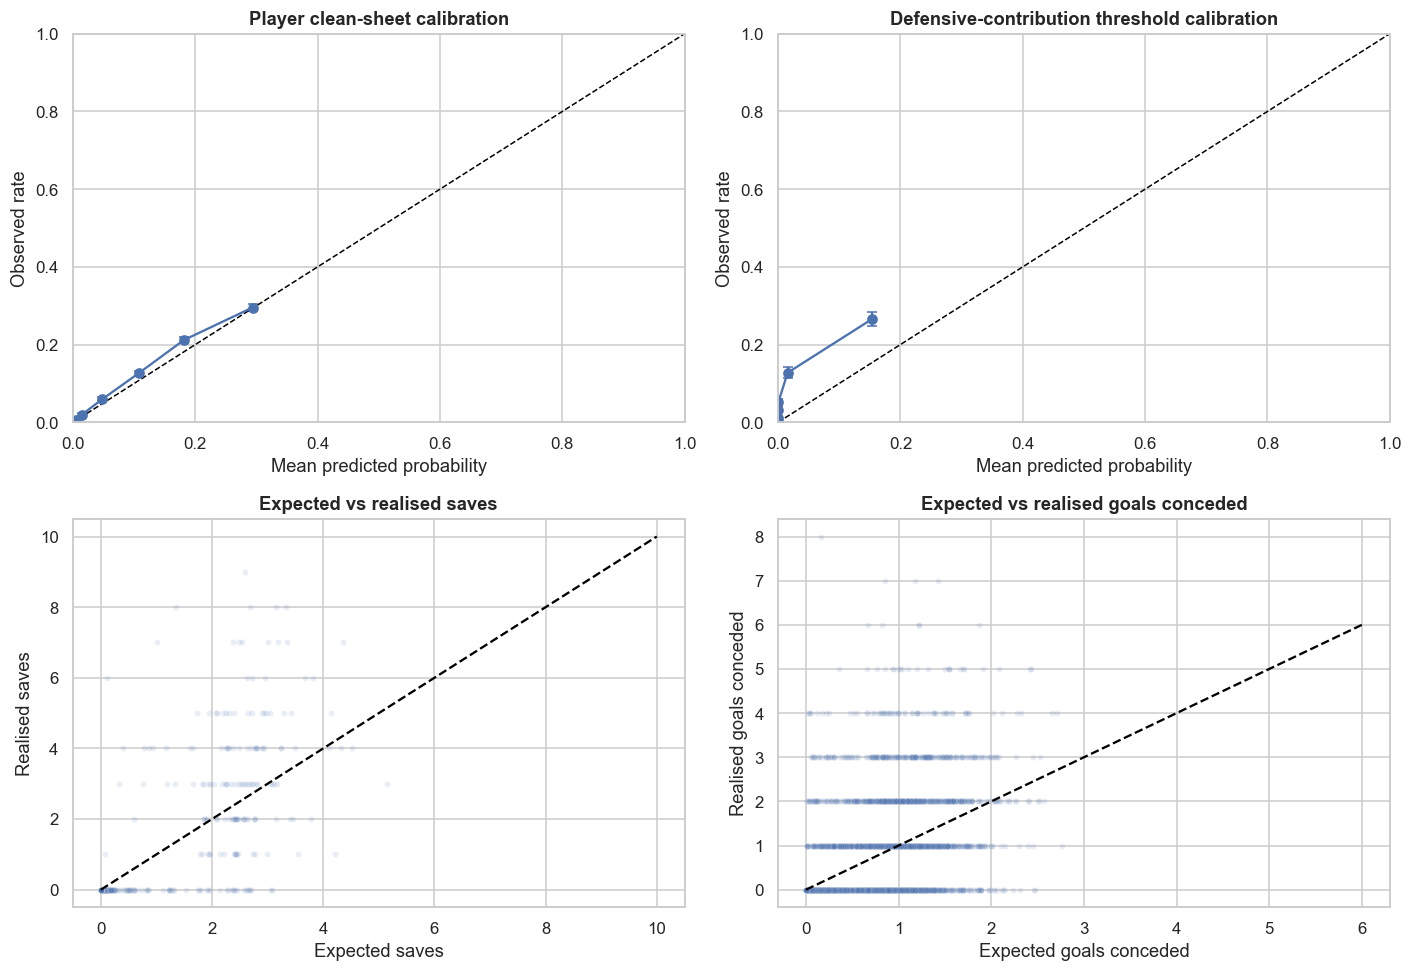

In [13]:
defensive_position = []
for position, group in defensive.groupby('position'):
    row = {'position': position, 'n': len(group)}
    row.update({f'saves_{key}': value for key, value in count_metrics(group, 'actual_saves', 'expected_saves').items() if key not in {'metric', 'n'}})
    row.update({f'clean_sheet_{key}': value for key, value in binary_metrics(group, 'actual_clean_sheet', 'player_clean_sheet_probability').items() if key not in {'metric', 'n'}})
    defensive_position.append(row)
display(pd.DataFrame(defensive_position))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_calibration(defensive, 'actual_clean_sheet', 'player_clean_sheet_probability', 'Player clean-sheet calibration', axes[0, 0])
if len(defcon):
    plot_calibration(defcon, 'actual_defcon_threshold', 'defensive_contribution_points_probability', 'Defensive-contribution threshold calibration', axes[0, 1])
else:
    axes[0, 1].set_title('Defensive-contribution calibration (no scored rows)')
sns.scatterplot(data=defensive.sample(min(6000, len(defensive)), random_state=7), x='expected_saves', y='actual_saves', alpha=0.12, s=15, ax=axes[1, 0])
axes[1, 0].plot([0, 10], [0, 10], '--', color='black')
axes[1, 0].set(title='Expected vs realised saves', xlabel='Expected saves', ylabel='Realised saves')
gk_def = defensive.loc[defensive['position'].isin(['GK', 'DEF'])]
sns.scatterplot(data=gk_def.sample(min(6000, len(gk_def)), random_state=7), x='expected_goals_conceded', y='actual_goals_conceded', alpha=0.12, s=15, ax=axes[1, 1])
axes[1, 1].plot([0, 6], [0, 6], '--', color='black')
axes[1, 1].set(title='Expected vs realised goals conceded', xlabel='Expected goals conceded', ylabel='Realised goals conceded')
plt.tight_layout()

## 6. Miscellaneous-event model

Cards, own goals, and penalty misses are rare. Their raw MAE can look deceptively small, so the table includes event rates, probability scores, and count deviance. The `position-prior` comparison is read from the model artifact to show whether the learned event rates improve on the deliberately simple baseline.

In [14]:
misc = predictions['misc_events'].copy()
misc_specs = [
    ('yellow cards', 'actual_yellow_cards', 'expected_yellow_cards', 'yellow_card_probability'),
    ('red cards', 'actual_red_cards', 'expected_red_cards', 'red_card_probability'),
    ('own goals', 'actual_own_goals', 'expected_own_goals', 'own_goal_probability'),
    ('penalties missed', 'actual_penalties_missed', 'expected_penalties_missed', 'penalty_miss_probability'),
]
misc_rows = []
for label, actual_col, expected_col, probability_col in misc_specs:
    count_row = count_metrics(misc, actual_col, expected_col, label)
    event_frame = misc.assign(event_actual=misc[actual_col].gt(0))
    binary_row = binary_metrics(event_frame, 'event_actual', probability_col, f'{label} | any-event')
    misc_rows.append({**count_row, **{f'event_{key}': value for key, value in binary_row.items() if key not in {'metric', 'n'}}})
misc_metrics = pd.DataFrame(misc_rows)
display(misc_metrics)

,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance,event_actual_rate,event_predicted_rate,event_brier,event_log_loss,event_roc_auc
0,yellow cards,86755,0.0526,0.0556,0.0030,0.0945,0.2171,0.2408,0.0526,0.0518,0.0468,0.1695,0.8163
1,red cards,86755,0.0018,0.0010,-0.0008,0.0027,0.0421,0.0206,0.0018,0.0010,0.0018,0.0121,0.7966
2,own goals,86755,0.0014,0.0015,0.0001,0.0029,0.0383,0.0161,0.0014,0.0015,0.0014,0.0093,0.8551
3,penalties missed,86755,0.0005,0.0008,0.0003,0.0013,0.0220,0.0058,0.0004,0.0008,0.0004,0.0032,0.9347


,event,metric,model,position_prior_baseline
0,yellow cards,mae,0.0945,0.0869
1,yellow cards,rmse,0.2171,0.2158
2,yellow cards,poisson_deviance,0.2408,0.2409
3,yellow cards,brier,0.0468,0.0466
4,red cards,mae,0.0027,0.0027
5,red cards,rmse,0.0421,0.0421
6,red cards,poisson_deviance,0.0206,0.0206
7,red cards,brier,0.0018,0.0018
8,own goals,mae,0.0029,0.0030
9,own goals,rmse,0.0383,0.0383


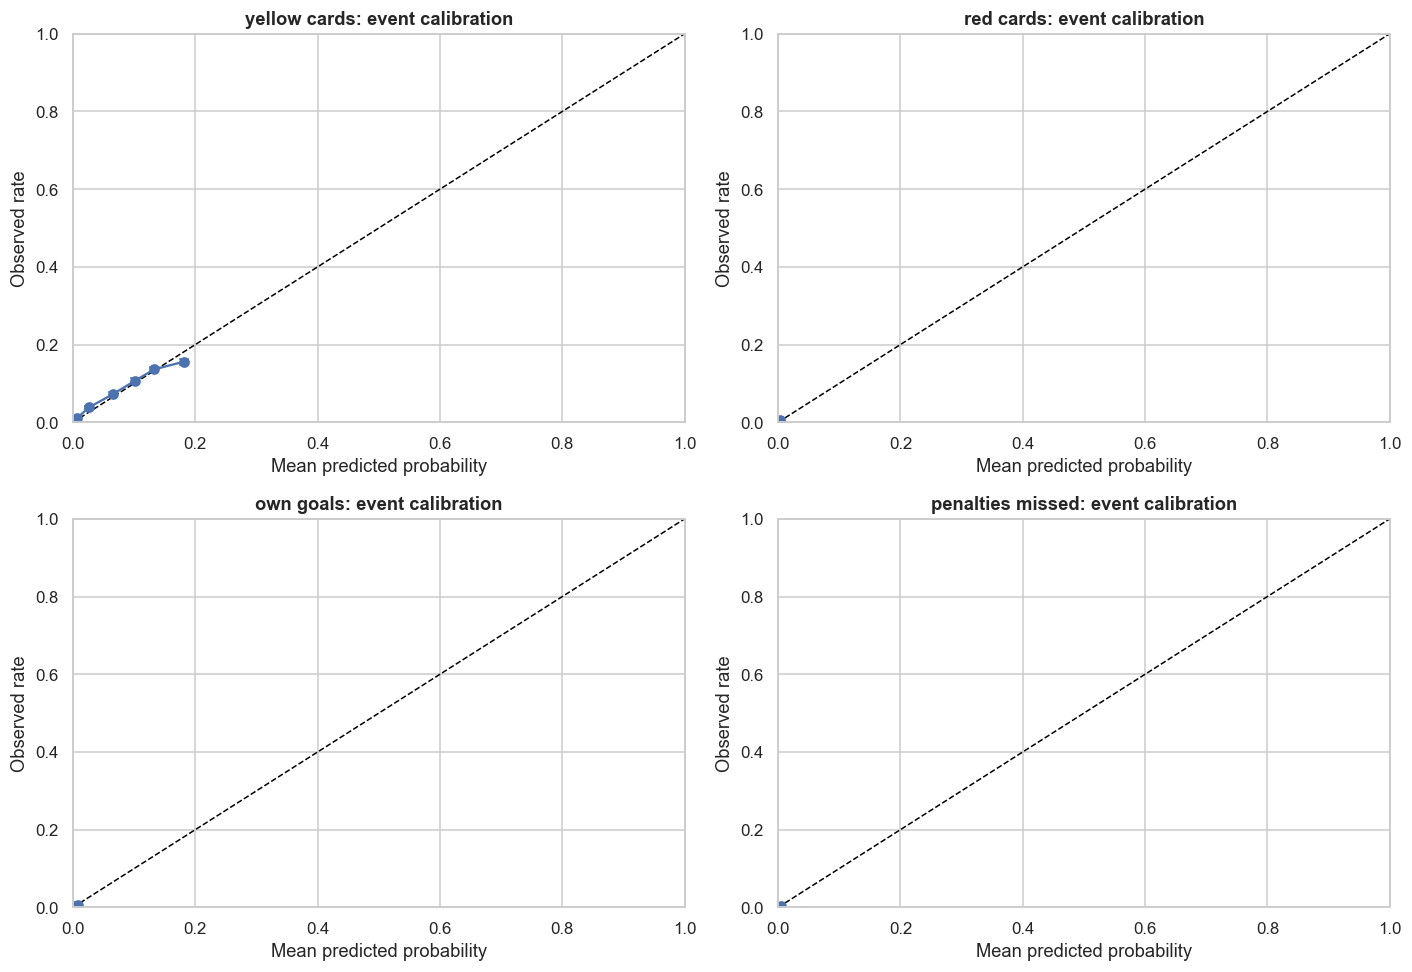

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (label, actual_col, expected_col, probability_col) in zip(axes.flat, misc_specs):
    frame = misc.assign(event_actual=misc[actual_col].gt(0))
    plot_calibration(frame, 'event_actual', probability_col, f'{label}: event calibration', ax)
plt.tight_layout()

misc_packaged = packaged_metrics['misc_events']
baseline_rows = []
model_section = misc_packaged.get('walk_forward_model', {})
baseline_section = misc_packaged.get('walk_forward_position_prior_baseline', {})
for label, _, _, _ in misc_specs:
    key = label.replace(' ', '_')
    if key in model_section and key in baseline_section:
        for metric_name in ['mae', 'rmse', 'poisson_deviance', 'brier']:
            baseline_rows.append({'event': label, 'metric': metric_name, 'model': model_section[key].get(metric_name), 'position_prior_baseline': baseline_section[key].get(metric_name)})
display(pd.DataFrame(baseline_rows))

## 7. Bonus/BPS model

BPS is continuous and highly zero-inflated at the unconditional player-fixture grain, so both unconditional and appeared-only errors are shown. Bonus is a four-class outcome (0–3 points); the multiclass probability distribution and the simpler any-bonus probability are evaluated independently.

In [16]:
bonus = predictions['bonus'].copy()
bonus_metrics = pd.DataFrame([
    count_metrics(bonus, 'actual_bps', 'expected_bps', 'BPS | unconditional', poisson=False),
    count_metrics(bonus.loc[bonus['actual_appeared'].eq(1)], 'actual_bps', 'conditional_expected_bps', 'BPS | appeared only', poisson=False),
    count_metrics(bonus, 'actual_bonus', 'expected_bonus', 'bonus points'),
])
bonus_probabilities = bonus[[f'bonus_{points}_probability' for points in range(4)]].to_numpy(float)
bonus_probabilities = bonus_probabilities / bonus_probabilities.sum(axis=1, keepdims=True)
bonus_actual = bonus['actual_bonus'].astype(int).to_numpy()
bonus_distribution_metrics = pd.DataFrame([{
    'rows': len(bonus),
    'bonus_multiclass_log_loss': log_loss(bonus_actual, bonus_probabilities, labels=[0, 1, 2, 3]),
    'bonus_multiclass_brier': multiclass_brier(bonus_actual, bonus_probabilities),
    'any_bonus_brier': brier_score_loss((bonus_actual > 0).astype(int), 1 - bonus_probabilities[:, 0]),
}])
display(bonus_metrics)
display(bonus_distribution_metrics)

,metric,n,actual_mean,predicted_mean,bias_pred_minus_actual,mae,rmse,poisson_deviance
0,BPS | unconditional,57030,4.6334,4.0433,-0.5901,3.5548,7.1778,NaN
1,BPS | appeared only,23058,11.4599,10.8293,-0.6306,7.5620,10.5201,NaN
2,bonus points,57030,0.0844,0.0851,0.0006,0.1364,0.3962,0.3351


,rows,bonus_multiclass_log_loss,bonus_multiclass_brier,any_bonus_brier
0,57030,0.1666,0.0724,0.0335


,season,position,n,bps_actual_mean,bps_predicted_mean,bps_bias_pred_minus_actual,bps_mae,bps_rmse,bps_poisson_deviance,bonus_actual_mean,bonus_predicted_mean,bonus_bias_pred_minus_actual,bonus_mae,bonus_rmse,bonus_poisson_deviance
0,2024-25,DEF,9146,4.1651,5.5337,1.3686,3.9087,6.6628,NaN,0.0616,0.0864,0.0248,0.1199,0.3295,0.2691
1,2024-25,FWD,3018,5.0755,4.2177,-0.8578,4.0651,8.8924,NaN,0.1925,0.1374,-0.0551,0.2331,0.5714,0.4918
2,2024-25,GK,2869,3.3325,5.0160,1.6835,3.0425,6.1364,NaN,0.0533,0.1001,0.0468,0.1198,0.3168,0.2470
3,2024-25,MID,12250,5.4360,4.8757,-0.5603,3.5216,6.6885,NaN,0.0901,0.0768,-0.0133,0.1277,0.3943,0.3065
4,2025-26,DEF,9733,4.5507,3.4947,-1.0560,3.8592,7.4948,NaN,0.0695,0.0836,0.0141,0.1306,0.3655,0.3401
5,2025-26,FWD,3278,4.6721,2.7505,-1.9216,3.9985,9.5957,NaN,0.1461,0.1216,-0.0245,0.2177,0.5469,0.5528
6,2025-26,GK,3427,3.1777,2.2579,-0.9198,2.2623,5.7952,NaN,0.0473,0.0568,0.0095,0.0911,0.3143,0.2419
7,2025-26,MID,13309,4.8222,3.1830,-1.6392,3.3379,7.1156,NaN,0.0825,0.0761,-0.0064,0.1331,0.4032,0.3571


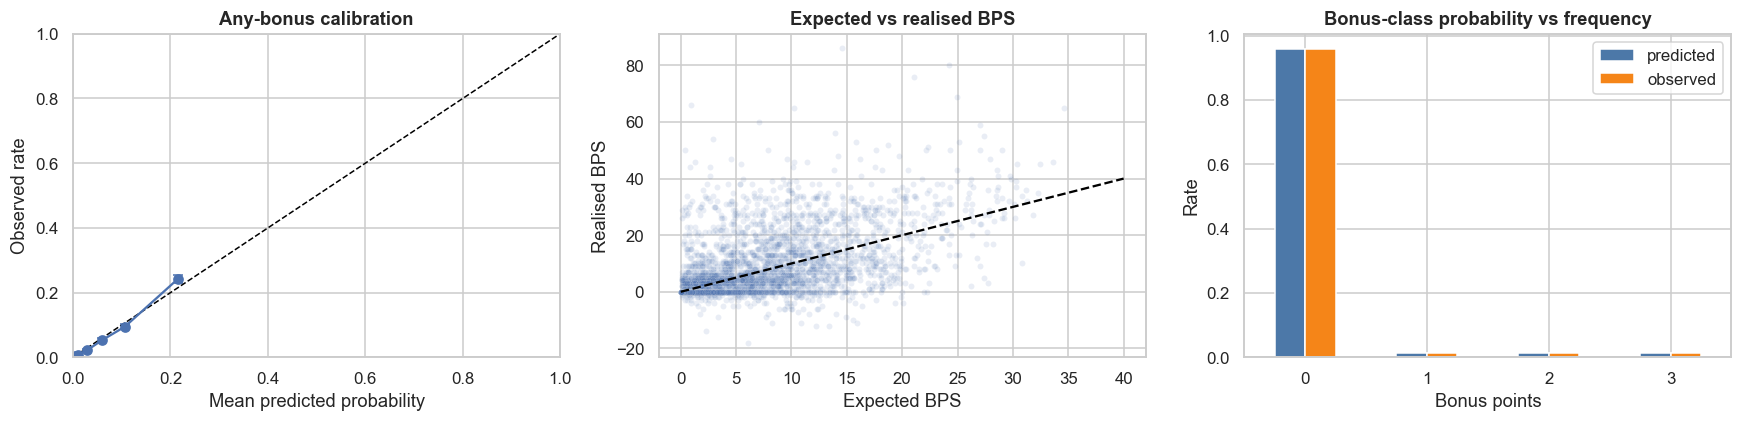

In [17]:
bonus_by_season_position = []
for (season, position), group in bonus.groupby(['season', 'position']):
    row = {'season': season, 'position': position, 'n': len(group)}
    row.update({f'bps_{key}': value for key, value in count_metrics(group, 'actual_bps', 'expected_bps', poisson=False).items() if key not in {'metric', 'n'}})
    row.update({f'bonus_{key}': value for key, value in count_metrics(group, 'actual_bonus', 'expected_bonus').items() if key not in {'metric', 'n'}})
    bonus_by_season_position.append(row)
display(pd.DataFrame(bonus_by_season_position))

bonus_calibration = bonus.assign(any_bonus_actual=bonus['actual_bonus'].gt(0), any_bonus_probability=1 - bonus['bonus_0_probability'])
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_calibration(bonus_calibration, 'any_bonus_actual', 'any_bonus_probability', 'Any-bonus calibration', axes[0])
sns.scatterplot(data=bonus.sample(min(6000, len(bonus)), random_state=7), x='expected_bps', y='actual_bps', alpha=0.12, s=15, ax=axes[1])
axes[1].plot([0, 40], [0, 40], '--', color='black')
axes[1].set(title='Expected vs realised BPS', xlabel='Expected BPS', ylabel='Realised BPS')
bonus_distribution = pd.DataFrame({
    'predicted': bonus_probabilities.mean(axis=0),
    'observed': [(bonus_actual == points).mean() for points in range(4)],
}, index=['0', '1', '2', '3'])
bonus_distribution.plot.bar(ax=axes[2], color=['#4c78a8', '#f58518'])
axes[2].set(title='Bonus-class probability vs frequency', xlabel='Bonus points', ylabel='Rate')
axes[2].tick_params(axis='x', rotation=0)
plt.tight_layout()

## 8. Reconstructing and evaluating overall xPts

The expected score is the sum of expected point contributions from the component forecasts. The names below mirror the inference scoring engine. For historical comparability, the 2024–25 expected defensive-contribution points are removed because those points were not part of that season's realised `total_points`; the 2025–26 holdout retains them. The exact realised component sum is checked against the source `target_total_points` before evaluation.

In [18]:
component_columns = {
    'minutes': ['appearance_probability', 'sixty_plus_probability'],
    'attacking': ['expected_goals', 'expected_fpl_assists'],
    'defensive': ['expected_clean_sheet_points', 'expected_goals_conceded_deduction', 'expected_save_points', 'expected_penalty_save_points', 'expected_defensive_contribution_points'],
    'misc': ['expected_misc_fpl_points'],
    'bonus': ['expected_bonus'],
}
overall = predictions['minutes_state'][
    PLAYER_KEYS + ['season_start', 'gameweek', 'kickoff_time', 'player_id', 'player_name', 'position', 'team_name', 'opponent_team_name', 'is_home'] + component_columns['minutes'] + ['expected_minutes']
].copy()
for source_name in ['attacking', 'defensive', 'misc_events', 'bonus']:
    columns = component_columns['attacking'] if source_name == 'attacking' else component_columns['defensive'] if source_name == 'defensive' else component_columns['misc'] if source_name == 'misc_events' else component_columns['bonus']
    overall = overall.merge(predictions[source_name][PLAYER_KEYS + columns], on=PLAYER_KEYS, how='inner', validate='one_to_one')

actual_columns = PLAYER_KEYS + [
    'target_total_points', 'target_appeared', 'target_sixty_plus', 'target_goals_scored', 'target_assists',
    'target_clean_sheets', 'target_goals_conceded', 'target_saves', 'target_penalties_saved', 'target_bonus',
    'target_defensive_contribution', 'target_yellow_cards', 'target_red_cards', 'target_own_goals', 'target_penalties_missed',
]
actuals = pd.read_csv(DATA_ROOT / 'processed' / 'model_training.csv', usecols=actual_columns, low_memory=False)
overall = overall.merge(actuals, on=PLAYER_KEYS, how='left', validate='one_to_one')
assert len(overall) == len(predictions['bonus'])
assert overall['target_total_points'].notna().all()

goal_points = overall['position'].map(RULES['goal']).astype(float)
clean_sheet_points = overall['position'].map(RULES['clean_sheet']).astype(float)
defcon_threshold = overall['position'].map(RULES['defensive_contribution_threshold']).fillna(np.inf)

expected_point_columns = {
    'appearance': (overall['appearance_probability'] - overall['sixty_plus_probability']) * RULES['appearance_under_60'] + overall['sixty_plus_probability'] * RULES['appearance_60_plus'],
    'goals': overall['expected_goals'] * goal_points,
    'assists': overall['expected_fpl_assists'] * RULES['assist'],
    'clean_sheet': overall['expected_clean_sheet_points'],
    'goals_conceded': overall['expected_goals_conceded_deduction'],
    'saves': overall['expected_save_points'],
    'penalty_saves': overall['expected_penalty_save_points'],
    'defensive_contributions': overall['expected_defensive_contribution_points'],
    'misc_events': overall['expected_misc_fpl_points'],
    'bonus': overall['expected_bonus'],
}
for name, values in expected_point_columns.items():
    overall[f'x_{name}'] = values
overall['xpts_current_rules'] = overall[[f'x_{name}' for name in expected_point_columns]].sum(axis=1)
overall['xpts_historical_comparable'] = overall['xpts_current_rules'] - overall['x_defensive_contributions'].where(overall['season'].eq('2024-25'), 0)
overall['xpts_for_evaluation'] = np.where(overall['season'].eq('2024-25'), overall['xpts_historical_comparable'], overall['xpts_current_rules'])

actual_point_columns = {
    'appearance': np.where(overall['target_appeared'].eq(1), np.where(overall['target_sixty_plus'].eq(1), RULES['appearance_60_plus'], RULES['appearance_under_60']), 0),
    'goals': overall['target_goals_scored'].fillna(0) * goal_points,
    'assists': overall['target_assists'].fillna(0) * RULES['assist'],
    'clean_sheet': overall['target_clean_sheets'].fillna(0) * overall['target_sixty_plus'].fillna(0) * clean_sheet_points,
    'goals_conceded': np.where(overall['position'].isin(['GK', 'DEF']), -(overall['target_goals_conceded'].fillna(0) // RULES['goals_conceded_per_deduction']), 0),
    'saves': overall['target_saves'].fillna(0) // RULES['saves_per_point'],
    'penalty_saves': overall['target_penalties_saved'].fillna(0) * RULES['penalty_save'],
    'defensive_contributions': np.where(overall['target_defensive_contribution'].notna(), (overall['target_defensive_contribution'].fillna(0) >= defcon_threshold) * RULES['defensive_contribution_points'], 0),
    'misc_events': -overall['target_yellow_cards'].fillna(0) - 3 * overall['target_red_cards'].fillna(0) - 2 * overall['target_own_goals'].fillna(0) - 2 * overall['target_penalties_missed'].fillna(0),
    'bonus': overall['target_bonus'].fillna(0),
}
for name, values in actual_point_columns.items():
    overall[f'a_{name}'] = values
overall['actual_points_from_components'] = overall[[f'a_{name}' for name in actual_point_columns]].sum(axis=1)

reconciliation = overall.groupby('season').agg(
    rows=('player_key', 'size'),
    target_mean=('target_total_points', 'mean'),
    component_sum_mean=('actual_points_from_components', 'mean'),
    max_abs_difference=('target_total_points', lambda values: 0),
).reset_index()
reconciliation['mean_difference'] = overall.groupby('season').apply(lambda group: (group['actual_points_from_components'] - group['target_total_points']).mean(), include_groups=False).to_numpy()
reconciliation['max_abs_difference'] = overall.groupby('season').apply(lambda group: (group['actual_points_from_components'] - group['target_total_points']).abs().max(), include_groups=False).to_numpy()
display(reconciliation)
assert np.allclose(overall['actual_points_from_components'], overall['target_total_points'], atol=1e-8)
print(f'Overall evaluation rows: {len(overall):,}; player-fixtures: {overall[PLAYER_KEYS].drop_duplicates().shape[0]:,}')

,season,rows,target_mean,component_sum_mean,max_abs_difference,mean_difference
0,2024-25,27283,1.1469,1.1469,0.0000,0.0000
1,2025-26,29747,1.1558,1.1558,0.0000,0.0000


Overall evaluation rows: 57,030; player-fixtures: 57,030


In [19]:
def overall_metrics(frame, prediction_col='xpts_for_evaluation'):
    actual, predicted = valid_arrays(frame['target_total_points'], frame[prediction_col])
    rank = spearmanr(actual, predicted)
    return {
        'rows': len(actual),
        'actual_mean': actual.mean(),
        'xpts_mean': predicted.mean(),
        'bias_xpts_minus_actual': (predicted - actual).mean(),
        'mae': mean_absolute_error(actual, predicted),
        'rmse': np.sqrt(mean_squared_error(actual, predicted)),
        'median_absolute_error': np.median(np.abs(predicted - actual)),
        'pearson_r': np.corrcoef(actual, predicted)[0, 1],
        'spearman_r': rank.statistic,
    }

overall_summary = pd.DataFrame([
    {'evaluation': '2024-25 | historical-scoring comparable', **overall_metrics(overall.loc[overall['season'].eq('2024-25')])},
    {'evaluation': '2025-26 | current-rules holdout', **overall_metrics(overall.loc[overall['season'].eq('2025-26')])},
    {'evaluation': 'pooled | mixed-era, adjusted', **overall_metrics(overall)},
])
display(overall_summary)

overall['expected_minutes_band'] = pd.cut(overall['expected_minutes'], [-np.inf, 30, 60, 75, np.inf], labels=['0–30', '30–60', '60–75', '75+'])
overall_groups = []
for group_name, group in overall.groupby('position'):
    overall_groups.append({'group': f'position: {group_name}', **overall_metrics(group)})
for group_name, group in overall.groupby('expected_minutes_band', observed=True):
    overall_groups.append({'group': f'expected minutes: {group_name}', **overall_metrics(group)})
display(pd.DataFrame(overall_groups))

,evaluation,rows,actual_mean,xpts_mean,bias_xpts_minus_actual,mae,rmse,median_absolute_error,pearson_r,spearman_r
0,2024-25 | historical-scoring comparable,27283,1.1469,1.1638,0.0170,0.9277,1.8044,0.2895,0.6265,0.7480
1,2025-26 | current-rules holdout,29747,1.1558,1.0898,-0.0660,0.9067,1.8578,0.1943,0.6152,0.7497
2,"pooled | mixed-era, adjusted",57030,1.1515,1.1252,-0.0263,0.9167,1.8324,0.2405,0.6202,0.7494


,group,rows,actual_mean,xpts_mean,bias_xpts_minus_actual,mae,rmse,median_absolute_error,pearson_r,spearman_r
0,position: DEF,18879,1.1254,1.1315,0.0061,1.0234,1.9031,0.3332,0.5761,0.6922
1,position: FWD,6296,1.3159,1.2085,-0.1075,1.0045,2.0274,0.2640,0.6421,0.8002
2,position: GK,6296,0.8116,0.8449,0.0333,0.6361,1.4372,0.0587,0.6832,0.6939
3,position: MID,25559,1.2141,1.1691,-0.0449,0.8854,1.8154,0.2659,0.6311,0.7784
4,expected minutes: 0–30,36424,0.2337,0.2445,0.0108,0.2820,0.8320,0.0618,0.4878,0.4865
5,expected minutes: 30–60,7304,2.0175,1.8728,-0.1447,1.6429,2.4964,1.1436,0.3451,0.3602
6,expected minutes: 60–75,5847,2.8136,2.7726,-0.0410,2.0879,2.8778,1.6299,0.3187,0.3081
7,expected minutes: 75+,7455,3.4837,3.4037,-0.0800,2.3878,3.1151,1.9736,0.3264,0.3083


,n,mean_xpts,mean_actual,actual_sd,ci95,bias
0,5703,0.0036,0.0002,0.0132,0.0003,0.0034
1,5703,0.0089,0.0014,0.0419,0.0011,0.0075
2,5703,0.0390,0.0096,0.1667,0.0043,0.0294
3,5703,0.0812,0.0323,0.3292,0.0085,0.0490
4,5703,0.2245,0.1643,0.6842,0.0178,0.0602
5,5703,0.6785,0.6568,1.3840,0.0359,0.0217
6,5703,1.3777,1.3519,1.9689,0.0511,0.0258
7,5703,2.1017,2.1452,2.4330,0.0631,-0.0434
8,5703,2.8125,2.9309,2.8793,0.0747,-0.1184
9,5703,3.9246,4.2227,3.7065,0.0962,-0.2981


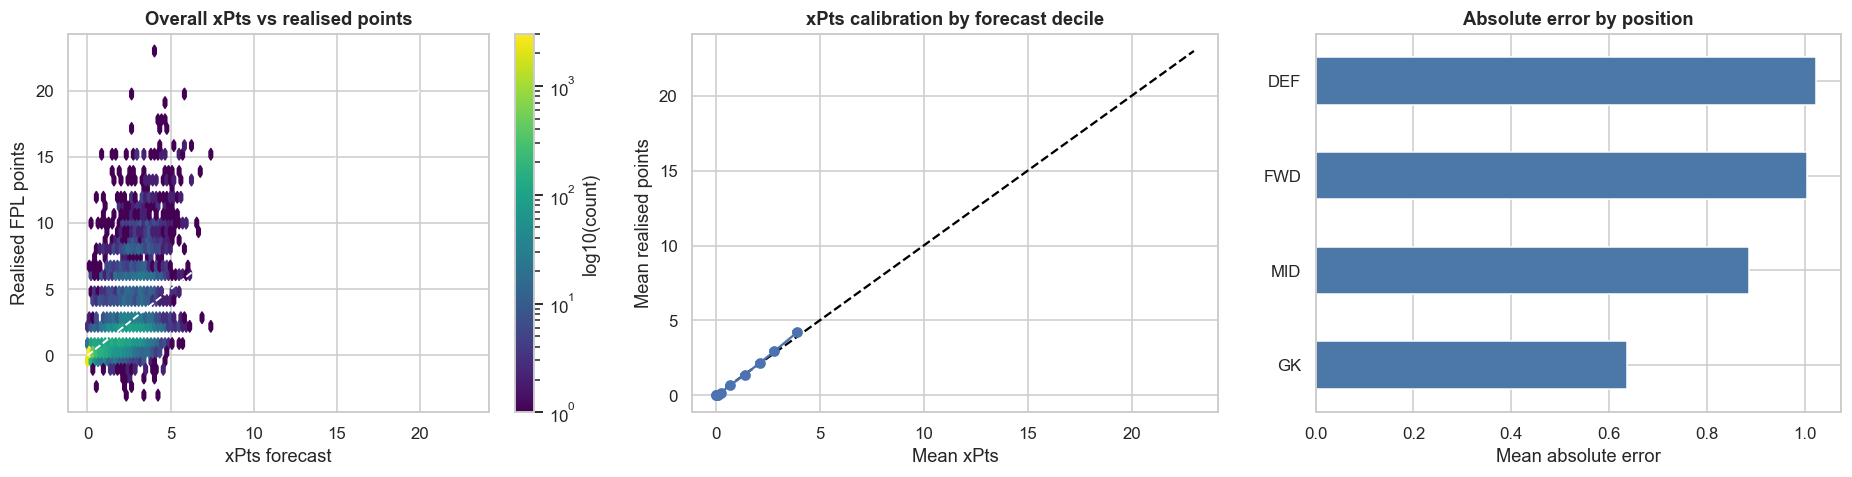

In [20]:
overall['xpts_decile'] = pd.qcut(overall['xpts_for_evaluation'], q=10, duplicates='drop')
xpts_calibration = overall.groupby('xpts_decile', observed=True).agg(
    n=('target_total_points', 'size'),
    mean_xpts=('xpts_for_evaluation', 'mean'),
    mean_actual=('target_total_points', 'mean'),
    actual_sd=('target_total_points', 'std'),
).reset_index(drop=True)
xpts_calibration['ci95'] = 1.96 * xpts_calibration['actual_sd'].fillna(0) / np.sqrt(xpts_calibration['n'])
xpts_calibration['bias'] = xpts_calibration['mean_xpts'] - xpts_calibration['mean_actual']
display(xpts_calibration)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
sample = overall.sample(min(12000, len(overall)), random_state=7)
hb = axes[0].hexbin(sample['xpts_for_evaluation'], sample['target_total_points'], gridsize=35, mincnt=1, bins='log', cmap='viridis')
max_points = max(sample['xpts_for_evaluation'].max(), sample['target_total_points'].max())
axes[0].plot([0, max_points], [0, max_points], '--', color='white', linewidth=1.2)
axes[0].set(title='Overall xPts vs realised points', xlabel='xPts forecast', ylabel='Realised FPL points')
fig.colorbar(hb, ax=axes[0], label='log10(count)')
axes[1].errorbar(xpts_calibration['mean_xpts'], xpts_calibration['mean_actual'], yerr=xpts_calibration['ci95'], fmt='o-', capsize=3)
axes[1].plot([0, max_points], [0, max_points], '--', color='black')
axes[1].set(title='xPts calibration by forecast decile', xlabel='Mean xPts', ylabel='Mean realised points')
position_error = overall.assign(abs_error=(overall['xpts_for_evaluation'] - overall['target_total_points']).abs()).groupby('position')['abs_error'].mean().sort_values()
position_error.plot.barh(ax=axes[2], color='#4c78a8')
axes[2].set(title='Absolute error by position', xlabel='Mean absolute error', ylabel='')
plt.tight_layout()

### Overall error decomposition

This compares each expected point contribution with the corresponding realised scoring component. It separates a model that is directionally right but noisy from a model with systematic under- or over-forecasting in one component. The expected columns use the historical-era adjustment above.

,component,expected_mean,actual_mean,bias,mae,share_of_total_abs_error
1,goals,0.1897,0.1758,0.0138,0.3081,0.3360
0,appearance,0.6809,0.6784,0.0025,0.2924,0.3190
3,clean sheet,0.1455,0.1672,-0.0217,0.2454,0.2677
2,assists,0.1053,0.1010,0.0043,0.1826,0.1992
9,bonus,0.0851,0.0844,0.0006,0.1364,0.1487
8,misc events,-0.0644,-0.0607,-0.0037,0.1086,0.1184
4,goals conceded,-0.0520,-0.0634,0.0114,0.0774,0.0844
7,defensive contributions,0.0182,0.0497,-0.0315,0.0577,0.0629
5,saves,0.0145,0.0169,-0.0024,0.0166,0.0181
6,penalty saves,0.0026,0.0022,0.0004,0.0047,0.0051


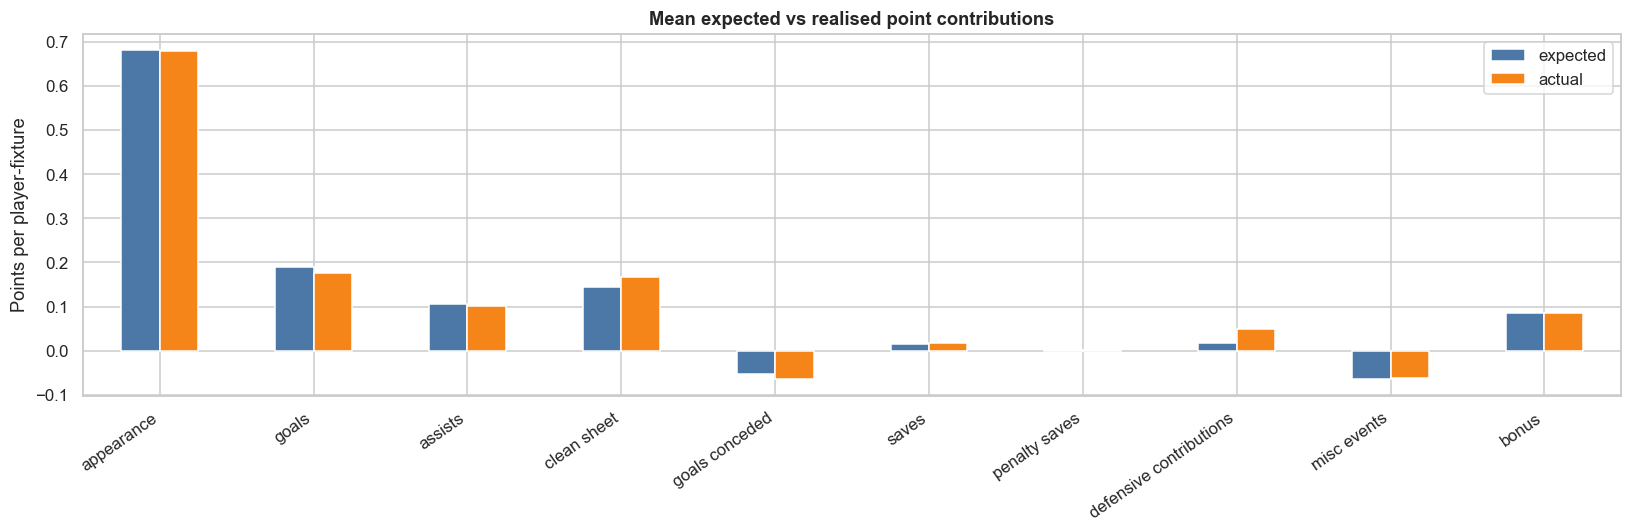

In [21]:
overall['x_defensive_contributions_comparable'] = overall['x_defensive_contributions'].where(overall['season'].eq('2025-26'), 0)
component_pairs = [
    ('appearance', 'x_appearance', 'a_appearance'),
    ('goals', 'x_goals', 'a_goals'),
    ('assists', 'x_assists', 'a_assists'),
    ('clean sheet', 'x_clean_sheet', 'a_clean_sheet'),
    ('goals conceded', 'x_goals_conceded', 'a_goals_conceded'),
    ('saves', 'x_saves', 'a_saves'),
    ('penalty saves', 'x_penalty_saves', 'a_penalty_saves'),
    ('defensive contributions', 'x_defensive_contributions_comparable', 'a_defensive_contributions'),
    ('misc events', 'x_misc_events', 'a_misc_events'),
    ('bonus', 'x_bonus', 'a_bonus'),
]
component_rows = []
for label, expected_col, actual_col in component_pairs:
    error = overall[expected_col] - overall[actual_col]
    component_rows.append({
        'component': label,
        'expected_mean': overall[expected_col].mean(),
        'actual_mean': overall[actual_col].mean(),
        'bias': error.mean(),
        'mae': error.abs().mean(),
        'share_of_total_abs_error': error.abs().sum() / np.abs(overall['xpts_for_evaluation'] - overall['target_total_points']).sum(),
    })
component_error_table = pd.DataFrame(component_rows).sort_values('mae', ascending=False)
display(component_error_table)

component_means = pd.DataFrame({
    'expected': [overall[expected_col].mean() for _, expected_col, _ in component_pairs],
    'actual': [overall[actual_col].mean() for _, _, actual_col in component_pairs],
}, index=[label for label, _, _ in component_pairs])
component_means.plot.bar(figsize=(15, 5), color=['#4c78a8', '#f58518'])
plt.title('Mean expected vs realised point contributions')
plt.ylabel('Points per player-fixture')
plt.xlabel('')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()

### Ranking usefulness at player-gameweek grain

A point forecast can be useful for selection even when exact points are noisy. The following metrics aggregate double gameweeks by player, calculate within-gameweek Spearman rank correlation, and measure top-k overlap with the realised points ranking. Ties are not tie-adjusted; this keeps the result deterministic and makes the selection rule explicit.

In [22]:
gameweek = overall.groupby(['season', 'gameweek', 'player_key', 'player_name', 'position'], as_index=False).agg(
    xpts=('xpts_for_evaluation', 'sum'),
    actual_points=('target_total_points', 'sum'),
    fixture_count=('fixture_id', 'nunique'),
)

def ranking_metrics(frame, ks=(5, 10, 20)):
    rows = []
    for k in ks:
        precisions, selected_points, baseline_points = [], [], []
        for _, group in frame.groupby(['season', 'gameweek']):
            if len(group) < k:
                continue
            predicted_top = set(group.nlargest(k, 'xpts')['player_key'])
            actual_top = set(group.nlargest(k, 'actual_points')['player_key'])
            precisions.append(len(predicted_top & actual_top) / k)
            selected_points.append(group.loc[group['player_key'].isin(predicted_top), 'actual_points'].mean())
            baseline_points.append(group['actual_points'].mean())
        rows.append({
            'k': k,
            'gameweeks': len(precisions),
            'top_k_overlap': np.mean(precisions),
            'actual_points_selected': np.mean(selected_points),
            'all_player_baseline': np.mean(baseline_points),
            'selection_lift': np.mean(selected_points) - np.mean(baseline_points),
        })
    return pd.DataFrame(rows)

rank_correlations = gameweek.groupby(['season', 'gameweek']).apply(
    lambda group: spearmanr(group['xpts'], group['actual_points']).statistic if len(group) > 2 and group['xpts'].nunique() > 1 and group['actual_points'].nunique() > 1 else np.nan,
    include_groups=False,
).rename('spearman_r').reset_index()
display(pd.DataFrame([{
    'gameweeks': rank_correlations['spearman_r'].notna().sum(),
    'mean_spearman_r': rank_correlations['spearman_r'].mean(),
    'median_spearman_r': rank_correlations['spearman_r'].median(),
}]))
display(ranking_metrics(gameweek))

,gameweeks,mean_spearman_r,median_spearman_r
0,76,0.7487,0.7504


,k,gameweeks,top_k_overlap,actual_points_selected,all_player_baseline,selection_lift
0,5,76,0.1658,7.0921,1.1694,5.9227
1,10,76,0.2066,6.2408,1.1694,5.0714
2,20,76,0.2566,5.6112,1.1694,4.4418


In [23]:
worst_cases = overall.assign(
    error=overall['xpts_for_evaluation'] - overall['target_total_points'],
    abs_error=(overall['xpts_for_evaluation'] - overall['target_total_points']).abs(),
)[['season', 'gameweek', 'player_name', 'position', 'team_name', 'opponent_team_name', 'expected_minutes', 'xpts_for_evaluation', 'target_total_points', 'error', 'abs_error']]
display(Markdown('**Largest absolute player-fixture errors**'))
display(worst_cases.nlargest(15, 'abs_error'))
display(Markdown('**Largest over-forecasts**'))
display(worst_cases.nlargest(10, 'error'))
display(Markdown('**Largest under-forecasts**'))
display(worst_cases.nsmallest(10, 'error'))

**Largest absolute player-fixture errors**

,season,gameweek,player_name,position,team_name,opponent_team_name,expected_minutes,xpts_for_evaluation,target_total_points,error,abs_error
28374,2025-26,2,Jurriën Timber,DEF,Arsenal,Leeds,45.8951,3.5888,24,-20.4112,20.4112
14204,2024-25,22,Justin Kluivert,MID,Bournemouth,Newcastle,62.5382,2.0189,22,-19.9811,19.9811
3421,2024-25,6,Cole Palmer,MID,Chelsea,Brighton,74.6033,5.6903,25,-19.3097,19.3097
33815,2025-26,9,Micky van de Ven,DEF,Spurs,Everton,73.3313,3.9644,23,-19.0356,19.0356
8048,2024-25,13,Kevin Schade,MID,Brentford,Leicester,27.6041,4.2315,23,-18.7685,18.7685
39473,2025-26,17,Keane Lewis-Potter,DEF,Brentford,Wolves,61.5368,2.9516,21,-18.0484,18.0484
1138,2024-25,2,Noni Madueke,MID,Chelsea,Wolves,16.3783,2.6522,20,-17.3478,17.3478
35974,2025-26,12,Eberechi Eze,MID,Arsenal,Spurs,73.3128,2.8735,20,-17.1265,17.1265
38751,2025-26,16,Callum Hudson-Odoi,MID,Nott'm Forest,Spurs,37.2515,1.9060,19,-17.0940,17.0940
51135,2025-26,32,Konstantinos Mavropanos,DEF,West Ham,Wolves,76.7559,3.9466,21,-17.0534,17.0534


**Largest over-forecasts**

,season,gameweek,player_name,position,team_name,opponent_team_name,expected_minutes,xpts_for_evaluation,target_total_points,error,abs_error
9994,2024-25,16,Andrew Robertson,DEF,Liverpool,Fulham,82.4471,4.3170,-3,7.3170,7.3170
30953,2025-26,6,Trevoh Chalobah,DEF,Chelsea,Brighton,82.6788,3.7922,-3,6.7922,6.7922
18672,2024-25,27,Patrick Dorgu,DEF,Man Utd,Ipswich,84.5167,3.7777,-3,6.7777,6.7777
30510,2025-26,5,Robert Lynch Sánchez,GK,Chelsea,Man Utd,81.0894,3.4395,-3,6.4395,6.4395
11748,2024-25,18,Bruno Borges Fernandes,MID,Man Utd,Wolves,80.6460,4.3813,-2,6.3813,6.3813
1257,2024-25,3,Declan Rice,MID,Arsenal,Brighton,80.4225,4.2929,-2,6.2929,6.2929
48434,2025-26,28,Erling Haaland,FWD,Man City,Leeds,79.4402,6.2315,0,6.2315,6.2315
26872,2024-25,38,Emiliano Martínez Romero,GK,Aston Villa,Man Utd,86.9762,4.0656,-2,6.0656,6.0656
50284,2025-26,30,Mohamed Salah,MID,Liverpool,Spurs,79.8238,7.0335,1,6.0335,6.0335
45219,2025-26,24,Neco Williams,DEF,Nott'm Forest,Crystal Palace,84.8906,3.9905,-2,5.9905,5.9905


**Largest under-forecasts**

,season,gameweek,player_name,position,team_name,opponent_team_name,expected_minutes,xpts_for_evaluation,target_total_points,error,abs_error
28374,2025-26,2,Jurriën Timber,DEF,Arsenal,Leeds,45.8951,3.5888,24,-20.4112,20.4112
14204,2024-25,22,Justin Kluivert,MID,Bournemouth,Newcastle,62.5382,2.0189,22,-19.9811,19.9811
3421,2024-25,6,Cole Palmer,MID,Chelsea,Brighton,74.6033,5.6903,25,-19.3097,19.3097
33815,2025-26,9,Micky van de Ven,DEF,Spurs,Everton,73.3313,3.9644,23,-19.0356,19.0356
8048,2024-25,13,Kevin Schade,MID,Brentford,Leicester,27.6041,4.2315,23,-18.7685,18.7685
39473,2025-26,17,Keane Lewis-Potter,DEF,Brentford,Wolves,61.5368,2.9516,21,-18.0484,18.0484
1138,2024-25,2,Noni Madueke,MID,Chelsea,Wolves,16.3783,2.6522,20,-17.3478,17.3478
35974,2025-26,12,Eberechi Eze,MID,Arsenal,Spurs,73.3128,2.8735,20,-17.1265,17.1265
38751,2025-26,16,Callum Hudson-Odoi,MID,Nott'm Forest,Spurs,37.2515,1.9060,19,-17.0940,17.0940
51135,2025-26,32,Konstantinos Mavropanos,DEF,West Ham,Wolves,76.7559,3.9466,21,-17.0534,17.0534


## 9. Recomputed metrics vs packaged metrics

This final cross-check makes silent changes in the persisted CSVs easier to detect. Small differences can come from rounding or changed metric definitions; large differences should be investigated before using the evaluation as a model-quality report.

In [24]:
cross_check = pd.DataFrame([
    {
        'model': 'team_score',
        'metric': 'goals_for_mae',
        'recomputed': count_metrics(team_score, 'actual_goals_for', 'expected_goals_for')['mae'],
        'packaged': packaged_metrics['team_score']['walk_forward_model']['all_validation_seasons']['goals_for_mae'],
    },
    {
        'model': 'minutes_state',
        'metric': 'minutes_mae',
        'recomputed': count_metrics(minutes, 'actual_minutes', 'expected_minutes')['mae'],
        'packaged': packaged_metrics['minutes_state']['walk_forward_model']['all_validation_seasons']['minutes_mae'],
    },
    {
        'model': 'attacking',
        'metric': 'goals_mae',
        'recomputed': count_metrics(attacking, 'actual_goals', 'expected_goals')['mae'],
        'packaged': packaged_metrics['attacking']['walk_forward_model']['all_validation_seasons']['goals_mae'],
    },
    {
        'model': 'bonus',
        'metric': 'bonus_mae',
        'recomputed': count_metrics(bonus, 'actual_bonus', 'expected_bonus')['mae'],
        'packaged': packaged_metrics['bonus']['walk_forward_model']['bonus_mae'],
    },
])
cross_check['absolute_difference'] = (cross_check['recomputed'] - cross_check['packaged']).abs()
display(cross_check)

,model,metric,recomputed,packaged,absolute_difference
0,team_score,goals_for_mae,0.9508,0.9508,0.0000
1,minutes_state,minutes_mae,12.2933,12.2933,0.0000
2,attacking,goals_mae,0.0631,0.0631,0.0000
3,bonus,bonus_mae,0.1364,0.1364,0.0000


## Interpretation checklist

When reviewing the output, focus on:

1. calibration drift by season, especially the latest holdout rather than only pooled averages;
2. expected-minutes bias, because it propagates into nearly every player-point component;
3. component bias and absolute-error contribution, not only the total xPts MAE;
4. top-k overlap and selection lift, which are closer to a fantasy decision use case than exact point accuracy;
5. rare-event log loss and event rates, rather than interpreting tiny rare-event MAEs as strong predictive performance;
6. the 2024–25 scoring-era adjustment and the fact that bonus forecasts only cover 2024–25 and 2025–26.

The overall evaluation should be read as an offline, leakage-safe validation of the current component contracts. It is not a claim that future fixture-level simulation intervals are calibrated: uncertainty intervals require realised historical simulation draws or persisted historical scoreline distributions, which are not part of the current artifacts.